# $$\textit{Implied $\mathbb{Q}$-calibration on German prices}$$

## Objective 
$$\min_{\vartheta_X} \sum_j w_j \left(C^{\rm mdl}(K_j, T_1^j, T_2^j; \vartheta_X) - C^{\rm mkt}(K_j, T_1^j, T_2^j)\right)^2 \quad \text{s.t.} \quad |\beta^\mathbb{P} + \vartheta_X| < \alpha^\mathbb{P}$$

## Method : Importance Sampling
First we simulate $N$ paths (once only) under $\mathbb{P}$, storing per path :
- $Z_\tau^{X,(i)}$ : CARMA state at $\tau$, reused across all tilts
- $L_\tau^{X,(i)} = \sum_k \Delta L_k^{X,(i)} $ : cumulated NIG driver over $[0,\tau]$, used for the Radon-Nikodym weight

We extend the function `simulate_state` to also return $L_\tau^{X,(i)} = \sum_k \Delta L^{X,(i)}_k$,
the cumulated NIG driver needed for the Radon-Nikodym weight.

For each $\vartheta_X$, the Esscher (PATHWISE) density is :
$$\mathcal{E}_\tau(\vartheta_X) = \exp\!\left(\vartheta_X \, L_\tau^{X,\mathbb{P}} - \tau \, \kappa_X^\mathbb{P}(\vartheta_X)\right)$$

and the model price is :
$$C^{\rm mdl}(K, T_1, T_2; \vartheta_X) = e^{-r\tau}\mathbb{E}\left[(F^{del}(\tau, T_1, T_2, \vartheta_X) - K)^+ \mathcal{E}_{\tau}(\vartheta_X)\right] = e^{-r\tau} \, \frac{\sum_i \mathcal{E}_\tau^{(i)} \, \left(F^{\rm del,(i)}(\tau, T_1, T_2,\vartheta_X) - K\right)^+}{\sum_i \mathcal{E}_\tau^{(i)}}$$

where $F^{\rm del,(i)}(\tau, T_1, T_2, \vartheta_X)$ reuses $Z_\tau^{X,(i)}$ but updates the deterministic cumulant integrals under $\mathbb{Q}^{\vartheta_X}$.

The implied volatility is in both case obtained inverting Black76.

### Esscher cumulant modification
Under the Esscher tilt $\vartheta_X$, the NIG cumulant exponent becomes :
$$\kappa_X^{\mathbb{Q},\vartheta_X}(u) = \kappa_X^\mathbb{P}(u + \vartheta_X) - \kappa_X^\mathbb{P}(\vartheta_X)$$

So the forward price formula (16) under $\mathbb{Q}^{\vartheta_X}$ is :
$$F^{\vartheta_X}(\tau, T) = \exp\!\left(\Lambda_S(T) + c_X^\top e^{A_X(T-\tau)} Z_\tau^X + \int_\tau^T \kappa_X^{\mathbb{Q},\vartheta_X}(\beta_X(s;T))\,ds\right)$$
assuming $\Gamma=0$ (no contribution of $\kappa_Y$).
The key point is that $Z_\tau^{X,(i)}$ is the same across tilts, only the deterministic integral changes.



### Delivery-period futures under $\mathbb{Q}^{\vartheta_X}$

It has the same structure as previous `delivery_futures` but uses $\kappa_X^{\mathbb{Q},\vartheta_X}$ instead of $\kappa_X^\mathbb{P}$.
The CARMA state sample $Z_\tau^{X,(i)}$ remain the same for all tilts.
$$F^{del}(\tau, T_1, T_2, {\vartheta_X}) = \sum_{i=1}^n \omega_i F^{\vartheta_X}(\tau, u_i)$$
For a baseload contract, $\omega_i = 1/n$


## Model Parameters 

In [19]:
import numpy as np
import pandas as pd
from scipy.linalg import expm
from scipy.stats import norm, norminvgauss
from scipy.integrate import quad
import matplotlib.pyplot as plt

# ------------------------------------------------------------------ CARMA parameters
# Log-price CARMA(5,4)
sig_X = 1

b0 = 4.892284940010e-06
b1 = 0.003871537896
b2 = 0.067247596781
b3 = 0.080860692901
b4 = 1.000000000000

a1 = 0.180878007791
a2 = 0.072955388459
a3 = 0.011876286348
a4 = 0.000206776833
a5 = 7.105208972921e-08


# NIG driver for X  
mu_X = 0.000740454873
delta_X = 0.006870223056
alpha_X = 47.467041650322
beta_X = -5.073598150809


# Dimension
pX = 5


#---------------------------------------------------------- Matrices for log prices X
'''The YUIMA convention holds'''

# Companion matrix A_X of shape (5, 5)
AX = np.array([[0,         1,          0,         0,         0],
               [0,         0,          1,         0,         0],
               [0,         0,          0,         1,         0],
               [0,         0,          0,         0,         1],
               [-a5,       -a4,       -a3,       -a2,      -a1]])

# Noise vector B_X of shape (5, 1)
BX =  np.array([[0   ], [0   ], [0   ], [0   ], [sig_X]])   

# Selection vector c_X of shape (5, 1)
cX = np.array([b0, b1, b2, b3, b4])                          



## Seasonality function

In [20]:
# ------------------------------------------------ Log-price seasonal function

file = r"C:\Users\nolan\PyCharmMiscProject\seasonalities.csv"
df = pd.read_csv(file, index_col=0, parse_dates=True)

seasonal_series = df["log_price_seasonal"].copy()
seasonal_series.index = pd.to_datetime(seasonal_series.index, utc=True)

lookup = (pd.DataFrame({"values"    : seasonal_series.values,            # return a dictionnary of tuples (m, dow, h)
                        "month"  : seasonal_series.index.month,       
                        "dow"    : seasonal_series.index.dayofweek,      # 0=monday ... 6=sunday
                        "hour"   : seasonal_series.index.hour})
                        .groupby(["month", "dow", "hour"])["values"]     # for example, (3, 2, 12) stands for 12h on a wednesday in march
                        .mean()                                          # we take the mean of the series values on the same dayofweek, hour, month
                        .to_dict())

def Lambda_S(t):                                                  # consistent with Paraschiv's method
    key = (t.month, t.dayofweek, t.hour)
    return lookup.get(key, np.nan)


# ------------------------------------------------ Discount factor

def discount_factor(r, t):
    return np.exp(-r * t / 8760)


#-------------------------------------------------------- Distance between two dates (hour)

def time_distance(end, start):                          
    return (end - start).total_seconds() / 3600


## Cumulant exponents & integration kernels, both under $\mathbb{P}$ and $\mathbb{Q}$

$$\kappa^\mathbb{P, Q}_X(u) = u\,\mu_X + \delta_X \,\left( \sqrt{\alpha_X^2 - (\beta_X^\mathbb{P, Q})^2}-\sqrt{\alpha_X^2 - (\beta_X^\mathbb{P, Q}+u)^2} \right) $$
$$\beta_X(s;T)
    = B_X^\top e^{(A_X^{\mathbb{P, Q}})^\top (T-s)} c_X$$

In [21]:
# ------------------------------------------------ Cumulant exponents
# -------- Under P

def kappa_X(u):
        return mu_X * u + delta_X * (np.sqrt(alpha_X**2 - beta_X**2) - np.sqrt(alpha_X**2 - (beta_X + u)**2))

# -------- Under Q

def kappa_X_Q(u, vartheta_X):
    beta = beta_X + vartheta_X + u
    arg = alpha_X**2 - beta**2
    if np.any(np.asarray(arg) < 0):
        print(f'[kappa_X_Q] NEGATIVE SQRT ARG: beta={beta}, 'f'alpha^2-beta^2={arg}, vartheta_X={vartheta_X}, u={u}')
    return kappa_X(u + vartheta_X) - kappa_X(vartheta_X)
    

# ------------------------------------------------ Integration kernel

def beta_X_kernel(s, T, cX, AX, BX):
    return float((cX.T @ expm(AX * (T - s)) @ BX)[0])


# ------------------------------------------------ Cumulant integrals
# -------- Under P

def integral_kappa_X(t, T):
    if T <= t:
        return 0.0
    f = lambda s: kappa_X(beta_X_kernel(s, T, cX, AX, BX))
    return quad(f, t, T, limit=200)[0]

# -------- Under Q

def integral_kappa_X_Q(t, T, vartheta_X):
    if T <= t:
        return 0.0
    f = lambda s: kappa_X_Q(beta_X_kernel(s, T, cX, AX, BX), vartheta_X)
    return quad(f, t, T, limit=200)[0]

## CARMA Price State Simulation

Given the state $Z^X_t$ at current time $t$, we simulate $Z^X_\tau$ for the option exercise date $\tau > t$ by iterating the exact discrete-time scheme :
$$Z^X_{t+\Delta t} = e^{A_X \Delta t}\,Z^X_t + \underbrace{A_X^{-1}(e^{A_X \Delta t}-I)B_X}_{M_X(\Delta t)}\,dL^X_t $$
where,
$$ dL^X_t \sim NIG(\alpha_X, \beta_X, \delta_X \,dt, \mu_X \,dt) $$

Remark : $$\mathbb{E}[dL_t^X]= \mu_X + \delta_X \, \frac{\beta_X}{\sqrt{\alpha_X^2 - \beta_X^2}} $$

In [22]:
#--------------------------------------------------------------- Strcutural matrices

def precompute_matrices(dt):         # here dt=1h
    eAXdt = expm(AX * dt)
    MX    = np.linalg.inv(AX) @ (eAXdt - np.eye(pX)) @ BX      # (5,1)
    return {'dt': dt, 'eAXdt': eAXdt, 'MX': MX}


#-------------------------------------------------------------- MC paths simulation
def simulate_state(maturity: float, N, dt: float = 1.0, seed: int = 0, vartheta: float = 0):
    """
    Simulate N paths of the CARMA state from time T0 to tau : maturity = time_distance(tau, T0)

    Returns
    ZX_tau : (N, pX)  state of X component at tau for all N paths
    """
    
    n_steps = int(maturity / dt)
    matrice = precompute_matrices(dt)
    eAXdt = matrice['eAXdt']
    MX = matrice['MX'].flatten()

    #rng = np.random.default_rng(seed)
    a_nig = alpha_X * delta_X
    b_nig = (beta_X + vartheta)  * delta_X       
    
    # Initialised paths (initial state at zero)
    ZX = np.zeros((N,pX)) # (N, pX)
    LX_cumulated = np.zeros(N)  #(N,)         #sum of the increments over [0,tau] (used for esscher change of measure in stage 2)
    
    for k in range(n_steps):
        
        dLX   = norminvgauss.rvs(a_nig, b_nig, loc=mu_X, scale=delta_X, size=N)#, random_state=rng.integers(2**31))
        
        ZX = ZX @ eAXdt.T 
        ZX += np.outer(dLX, MX)    # (N, pX) dLX of size (N, )
        LX_cumulated += dLX
    
    return ZX, LX_cumulated  # (N,pX), (N, )


## Forward Price Formula 

Given the CARMA state at time $\tau$ and a delivery date $T$, the forward price formula is:
$$F(\tau, T) = \exp\!\Bigl(\Lambda_S(T) + c_X^\top e^{A_X^{\mathbb{Q}}(T-\tau)} Z^X_\tau + \int_\tau^T \kappa^{\mathbb{Q}}_X(\beta_X(s;T))\,\mathrm{d}s \Bigr)\quad \quad \quad (16)$$

We compute N different prices for (N, 9) distinct initial states $Z^X_\tau$.

In [23]:
def forward_price_vectorised(ZX_tau: np.ndarray, tau: float, T: float, T_timestamp: pd.Timestamp, int_kappa_X) -> np.ndarray:
    """
    Compute F(tau, T) for N Monte-Carlo paths using equation (16).

    Parameters
    ZX_tau    : (N, 9)  N CARMA states at exercise time tau
    tau : elapsed hours from T0 to tau
    T   : elapsed hours from T0 to delivery date T
    T_timestamp : delivery date as Timestamp (for Lambda_S lookup)
    int_kappa_X : precomputed int_tau^T kappa_X(beta_X(s,T)) ds
    int_kappa_X : precomputed int_tau^T kappa_Y(gamma_X(s,T)) ds

    Returns
    F_tau_T : (N,)  forward prices
    """

    eAXh  = expm(AX * (T - tau))          # (pX,pX)  ;   T - tau = residual time to delivery (hours)

    X_bar_tau  = ZX_tau @ eAXh.T @ cX  # (N,)

    # Log-price seasonal at delivery date
    lam_s = Lambda_S(T_timestamp)      # scalar

    return np.exp(lam_s + X_bar_tau + int_kappa_X) - 1000      # (N,)       



## Delivery-period Electricity Futures

With a deterministic delivery grid $T_1 = u_1 < \cdots < u_n = T_2$ and weights $\omega_j$, the price of the future becomes :
$$F^{\rm del}(\tau; T_1, T_2) \approx \sum_{j=1}^{n} \omega_j\, F(\tau, u_j) \quad \quad \quad (26)$$

We use a uniform weighting over hourly grid points in $[T_1, T_2]$, i.e. $u_j = T_1 + (j-1) \quad \forall j \in \{1, ..., n\} \,\, with \,\,n = T_2 - T_1 + 1$ and $\omega_j= \frac{1}{T_2 - T_1 + 1} \,\, \forall j \in \{1, ..., n\}$

In [30]:
#--------------------------------------------------------------- Under either P or Q^vartheta


def delivery_futures(T1, T2, ZX_tau: np.ndarray, tau_hours: float, T0: pd.Timestamp, vartheta: float = 0) -> np.ndarray:
    """
    Compute the delivery-period futures price F^del(tau; T1, T2) under Q^vartheta_X for N paths using (26).

    Parameters
    T0            : pricing date (today)
    T1, T2        : delivery period 
    ZX_tau        : (N, pX)  CARMA X-state at tau (one per MC path)
    tau_hours     : elapsed hours from T0 to exercise date tau
    delivery_grid : list of Timestamps covering [T1, T2]
    origin_date   : reference origin date
    vartheta      : Esscher tilt parameter
    weights       : (n,) quadrature weights, uniform for a baseload

    Returns
    F_del : (N,)  delivery-period future price for each path under Q^vartheta_X
    """
    
    delivery_grid = list(pd.date_range(start=T1, end=T2, periods=int(time_distance(T2, T1))))
    n = len(delivery_grid)
    weights = np.ones(n) / n
   
    N = ZX_tau.shape[0]

    # Precompute cumulant integrals for each delivery point 
    int_kappa_X = np.zeros(n)
    for j, T_ts in enumerate(delivery_grid):
        T_h = time_distance(T_ts, T0)
        int_kappa_X[j] = integral_kappa_X_Q(tau_hours, T_h, vartheta)
    
    if not np.all(np.isfinite(int_kappa_X)):
        print(f'    [delivery_futures_Q] WARNING: non-finite cumulant integral 'f'at vartheta={vartheta:.6f}')
        print(f'    [delivery_futures_Q] int_kX_Q sample: {int_kappa_X_Q[:5]}')
    
    # Form the futures prices by taking the arithmetic average of the forward prices
    F_del = np.zeros(N)
    for j, T_ts in enumerate(delivery_grid):
        T_h = time_distance(T_ts, T0)
        F_j   = forward_price_vectorised(ZX_tau, tau_hours, T_h, T_ts, int_kappa_X[j])
        
        if not np.all(np.isfinite(F_j)):
            n_bad = np.sum(~np.isfinite(F_j))
            print(f'[delivery_futures_Q] WARNING: {n_bad}/{N} non-finite F_j ' f'at grid point j={j}, T={T_ts.date()}, vartheta={vartheta:.6f}')
        
        F_del += weights[j] * F_j

    return F_del  # (N,)




In [25]:
def delivery_futures(T1: pd.Timestamp, T2: pd.Timestamp,
                     ZX_tau: np.ndarray, tau_hours: float,
                     T0: pd.Timestamp) -> np.ndarray:
    """
    Vectorised delivery-period futures. Same interface as before, ~10-50x faster.

    Key optimisations vs the original :
    1. All matrix exponentials exp(AX*(T_h - tau)) precomputed once in a batch.
    2. X_bar = ZX_tau @ eAX.T @ cX computed for ALL grid points simultaneously
       via a single (N, n) matmul, avoiding the per-point loop in
       forward_price_vectorised.
    3. Cumulant integrals still use quad (unavoidable), but are the only serial loop.
    4. Lambda_S lookup vectorised over the grid via a list-comp on the timestamp.
    """
    delivery_grid = list(pd.date_range(
        start=T1, end=T2, periods=int(time_distance(T2, T1))
    ))
    n       = len(delivery_grid)
    weights = np.ones(n) / n
    N       = ZX_tau.shape[0]

    # ---------------------------------------------------------------- (1)
    # Precompute T_h values and matrix exponentials for every grid point
    T_h_vec = np.array([time_distance(T_ts, T0) for T_ts in delivery_grid])  # (n,)
    h_vec   = T_h_vec - tau_hours                                             # residual times (n,)

    # eAX_batch[j] = exp(AX * h_vec[j]),  shape (n, pX, pX)
    eAX_batch = np.stack([expm(AX * h) for h in h_vec], axis=0)

    # ---------------------------------------------------------------- (2)
    # X_bar[i, j] = cX @ exp(AX * h_j) @ ZX_tau[i]
    #             = (ZX_tau @ eAX_batch[j].T) @ cX
    # Vectorise over j with einsum : shape (N, n)
    #   eAX_cX[j] = exp(AX*h_j).T @ cX,  shape (n, pX)
    eAX_cX = np.einsum('jkl,l->jk', eAX_batch, cX)   # (n, pX)
    X_bar  = ZX_tau @ eAX_cX.T                         # (N, pX) @ (pX, n) -> (N, n)

    # ---------------------------------------------------------------- (3)
    # Cumulant integrals — still serial (quad), but called once per grid point
    int_kX = np.array([integral_kappa_X(tau_hours, T_h) for T_h in T_h_vec])  # (n,)
    #int_kY = np.array([integral_kappa_Y(tau_hours, T_h) for T_h in T_h_vec])  # (n,)

    # ---------------------------------------------------------------- (4)
    # Lambda_S for each grid point — simple lookup, vectorised over grid
    lam_S = np.array([Lambda_S(T_ts) for T_ts in delivery_grid])              # (n,)

    # ---------------------------------------------------------------- (5)
    # Log-forward matrix : log_F[i, j] = lam_S[j] + X_bar[i,j] + int_kX[j] + int_kY[j]
    # Shape (N, n) via broadcasting
    log_F = lam_S[None, :] + X_bar + int_kX[None, :] #+ int_kY[None, :]       # (N, n)

    # ---------------------------------------------------------------- (6)
    # Forward prices and weighted average  — all in one shot
    F_grid = np.exp(log_F) - 1000                                              # (N, n)
    F_del  = F_grid @ weights                                                  # (N,)

    return F_del

## Esscher weights and ESS diagnostic plot

$$\mathcal{E}_\tau^{(i)}(\vartheta_X) = \exp\!\left(\vartheta_X \, L_\tau^{X,(i)} - \tau \, \kappa_X^\mathbb{P}(\vartheta_X)\right)$$

Numerical stabilisation : subtract $\max_i \log w_i$ before exponentiating, it modifies neither the price nor the ESS but avoid exp(>>1) and exp(<<-1) which respectively induce infty and 0.

$$\frac{\mathrm{ESS}(\vartheta_X)}{N} = \frac{\left(\sum_i w_i\right)^2}{N \sum_i w_i^2} \in (0, 1]$$
Signification : if all weights are equal, $\omega_1 \approx \omega_2 \approx ... \omega_N$ then $ESS=N$, all paths contribute to the expectation. However, if  $\omega_1 \gg \omega_2, ..., \omega_N$ only one path is involved in the mean, ESS goes to 1 and the result is too noisy. The more $\vartheta_X$ gets far from the reference measure, the more weights are dispersed.

Sweep $\vartheta_X$ over the full strip and plot ESS/N ; verifies that importance sampling
remains reliable across the feasible region before running the optimiser.

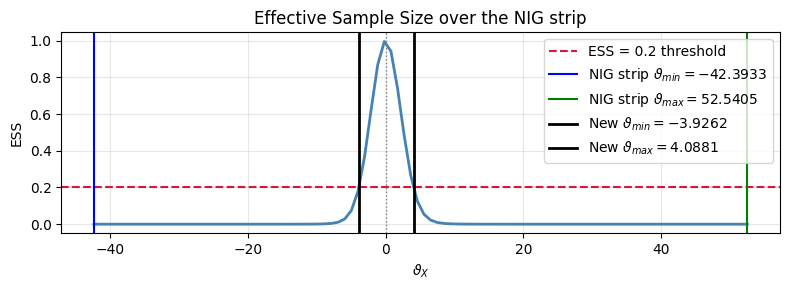

In [34]:
def esscher_weights(vartheta_X, LX_cumulated, tau_hours, vartheta_anchor=0):
    """
    Compute normalised Esscher IS weights for tilt vartheta_X relative to
    the simulation anchor vartheta_anchor.

    dQ^{vartheta_X} / dQ^{vartheta_anchor} (Ftau) = exp( (vartheta_X - vartheta_anchor) * L_tau - tau * (kappa_P(vartheta_X) - kappa_P(vartheta_anchor)))
    """
    delta = vartheta_X - vartheta_anchor

    log_w = delta * LX_cumulated - tau_hours * (kappa_X(vartheta_X) - kappa_X(vartheta_anchor))

    # diagnostic
    if not np.all(np.isfinite(log_w)):
        n_bad = np.sum(~np.isfinite(log_w))
        print(f'    [esscher_weights] WARNING: {n_bad}/{len(log_w)} non-finite log_w '
              f'(delta={delta:.6f}, kappa_diff={kappa_X(vartheta_X) - kappa_X(vartheta_anchor):.6e})')
        print(f'    [esscher_weights] LX_cumulated range: '
              f'[{LX_cumulated.min():.4f}, {LX_cumulated.max():.4f}]')

    log_w -= log_w.max()             # numerical stabilisation
    w      = np.exp(log_w)
    w_sum  = w.sum()

    if w_sum == 0 or not np.isfinite(w_sum):
        print(f'    [esscher_weights] CRITICAL: w.sum()={w_sum} -> degenerate weights')

    w_norm = w / w_sum          # self-normalised weights 
    ess    = 1.0 / (len(w) * np.sum(w_norm**2))
    return w_norm, ess


# --------------------------------------------------- ESS plot over the NIG strip

def ess_plot(LX_cumulated: np.ndarray, tau_hours: float, n_points: int = 100):
    """
    Plot ESS/N as a function of vartheta_X over the NIG strip.
    Call this after simulating to check IS reliability before optimising.
    """
    vartheta_min = -alpha_X - beta_X + 1e-4
    vartheta_max =  alpha_X - beta_X - 1e-4
    vartheta   = np.linspace(vartheta_min, vartheta_max, n_points)

    ess_vec = []
    for v in vartheta:
        _, ess = esscher_weights(v, LX_cumulated, tau_hours)
        ess_vec.append(ess)
    
    # ------------------------------------------------ Find ESS=0.2 crossings
    threshold = 0.2
    theta_crossings = []

    for i in range(len(vartheta) - 1):
        y1, y2 = ess_vec[i], ess_vec[i+1]

        if (y1 - threshold) * (y2 - threshold) < 0:
            # Linear interpolation
            x1, x2 = vartheta[i], vartheta[i+1]
            theta_star = x1 + (threshold - y1) * (x2 - x1) / (y2 - y1)
            theta_crossings.append(theta_star)

    theta_left = theta_crossings[0] if len(theta_crossings) >= 1 else None
    theta_right = theta_crossings[-1] if len(theta_crossings) >= 2 else None

    plt.figure(figsize=(8, 3))
    plt.plot(vartheta, ess_vec, 'steelblue', lw=2)
    plt.axhline(0.2, color='crimson', ls='--', lw=1.5, label='ESS = 0.2 threshold')
    plt.axvline(0.0, color='gray', ls=':', lw=1)
    plt.axvline(vartheta_min, color='blue', label=rf'NIG strip $\vartheta_{{min}}={vartheta_min:.4f}$')
    plt.axvline(vartheta_max, color='green', label=rf'NIG strip $\vartheta_{{max}}={vartheta_max:.4f}$')
    
    if theta_left is not None:
        plt.axvline(theta_left,
                    color='black',
                    lw=2,
                    label=rf'New $\vartheta_{{min}}={theta_left:.4f}$')

    if theta_right is not None:
        plt.axvline(theta_right,
                    color='black',
                    lw=2,
                    label=rf'New $\vartheta_{{max}}={theta_right:.4f}$')

    plt.xlabel(r'$\vartheta_X$')
    plt.ylabel('ESS')
    plt.title('Effective Sample Size over the NIG strip')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return vartheta, np.array(ess_vec)

# ---------------------------------------------------------------- ESS diagnostic (before optimising)
T0 = pd.Timestamp('2026-06-02 00:00:00')
tau = pd.Timestamp('2026-07-01 00:00:00')

tau_hours = time_distance(tau, T0)

_, LX = simulate_state(tau_hours, N=300_000, seed=0, vartheta = 0)  #simulate_state is fast
vartheta, ess = ess_plot(LX, tau_hours)


## Option on Futures Pricing with Monte-Carlo and Importance Sampling for a single tilt $\vartheta_X$
#### Pricing of a European call with payoff under either $\mathbb{P}$ or $\mathbb{Q}^{\vartheta}$
$$\mathbb{E}\left[(F^{del}(\tau; T_1, T_2) - K)^+ \right] \quad \text{under} \quad \mathbb{P} $$ 
$$\mathbb{E}\left[(F^{del}(\tau; T_1, T_2, \vartheta_X) - K)^+ \mathcal{E}_{\tau}(\vartheta_X) \right] \quad \text{under} \quad \mathbb{Q}^{\vartheta_X}$$ 


In [37]:
def price_futures_call(T0: pd.Timestamp, tau: pd.Timestamp, T1: pd.Timestamp, T2: pd.Timestamp,
                       K: float, origin_date: pd.Timestamp, ZX0: np.ndarray | None = None,
                       ZY0: np.ndarray | None = None, N: int = 10_000, r: float = 0.0,                       
                       dt: float = 1.0, seed: int = 0, confidence: float = 0.95, vartheta: float = 0) -> dict:
    
    """
    Price a call on the delivery-period electricity future under either P or Q^vartheta_X.

    Parameters
    T0            : today's date
    T1, T2        : delivery period 
    tau           : option expiry date tau
    delivery_grid : list of Timestamps covering [T1, T2]
    origin_date   : reference origin date
    vartheta_X  : Esscher tilt parameter
    weights       : (n,) quadrature weights, uniform for a baseload
    tau          : option exercise date (t<= tau <= T1)
    K            : strike price
    origin_date  : origin for seasonality
    ZX0, ZY0     : initial CARMA states at T0 (default : zero)

    Returns
    price, std_error, conf_interval, payoffs, F_del
    """
    
    assert tau >= T0
    assert tau <= T1

    maturity = int(time_distance(tau, T0))  #tau_hours

    if ZX0 is None:
        ZX0 = np.zeros(pX)
    
    # ---------------------------------------------------------------- Step (1)
    ZX_tau, LX_cumulated = simulate_state(maturity, N, dt, seed, vartheta) #here vartheta = 0 under P

    # ---------------------------------------------------------------- Step (2) + (3)
    F_del = delivery_futures(T1, T2, ZX_tau, maturity, T0, vartheta)

    # ---------------------------------------------------------------- Step (4)
    w_norm, ess = esscher_weights(vartheta, LX_cumulated, maturity)
    payoffs = np.maximum(F_del - K, 0.0)
    df      = discount_factor(r, maturity)
    price   = df * np.sum(w_norm * payoffs)
    se      = df * payoffs.std() / np.sqrt(N)
    z       = norm.ppf((1 + confidence) / 2)
    ci      = (price - z * se, price + z * se)

    return {'call price'  : price,
            'std_error': se,
            'conf_interval' : ci,
            'payoff distribution'  : payoffs,
            'F_del'    : F_del}


## Pricing test under $\mathbb{P}$ for verification
### Setting
- Current date $T_0$ : 2026-06-02 00:00:00
- Option exercise $\tau$ : 2026-07-01 00:00:00 (1 month maturity)
- Delivery period $[T_1, T_2]$ : July 2026
- Strike $K$ : $F^{\rm del}(0 ; T_1, T_2)$ (ATM), we compute the future price viewed from today

In [38]:

origin_date = pd.Timestamp('2023-01-01 00:00:00')   # origin for the temperature seasonnality function (need to be checked with Gabriel)
T0          = pd.Timestamp('2026-06-02 00:00:00')   # today
tau         = pd.Timestamp('2026-07-01 00:00:00')   # option expiry
T1          = pd.Timestamp('2026-07-01 00:00:00')   
T2          = pd.Timestamp('2026-07-31 23:00:00')
r = 0   
N = 100_000   

# Intial value
K = delivery_futures(T1, T2, np.zeros((1, pX)), 0, T0, vartheta = 0)[0] #ATM

#Call price
result = price_futures_call(T0=T0, tau=tau, T1=T1, T2=T2, K=K, origin_date=origin_date, N=N, r=r, dt=1.0, seed=0, vartheta = 0)


print('=' * 50)
print(f'  Strike K (ATM)       : {K:.2f}€/MWh')
print(f'  Mean future price    : {np.mean(result["F_del"]):.2f}€/MWh')
print(f'  Call price    : {result["call price"]:.2f}€/MWh')
print(f'  Std error            : {result["std_error"]:.4f}€/MWh')
ci = result['conf_interval']
print(f'  95% CI               : [{ci[0]:.4f}, {ci[1]:.4f}](€/MWh)')
print(f'  Relative error       : {result["std_error"]/result["call price"]*100:.2f}%')
print('=' * 50)

  Strike K (ATM)       : 77.63€/MWh
  Mean future price    : 77.60€/MWh
  Call price    : 2.18€/MWh
  Std error            : 0.0101€/MWh
  95% CI               : [2.1608, 2.2005](€/MWh)
  Relative error       : 0.46%


### Distributions

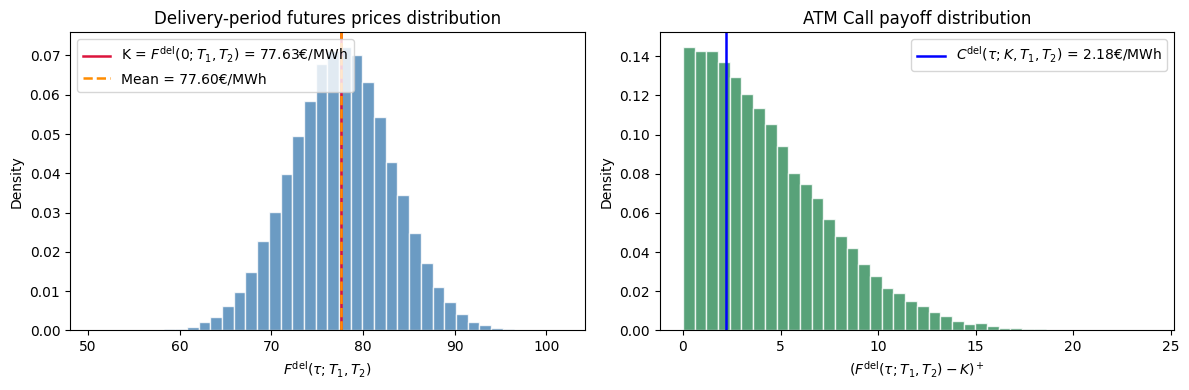

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram of Futures prices
axes[0].hist(result['F_del'], bins=40, density=True, color='steelblue', alpha=0.8, edgecolor='white')
axes[0].axvline(K, color='crimson', lw=1.8, label=fr'K = $F^{{\rm del}}(0; T_1, T_2)$ = {K:.2f}€/MWh')
axes[0].axvline(result['F_del'].mean(), color='darkorange', lw=1.8, ls='--',
                label=f'Mean = {result["F_del"].mean():.2f}€/MWh')
axes[0].set_xlabel('$F^{\\rm del}(\\tau; T_1, T_2)$')
axes[0].set_ylabel('Density')
axes[0].set_title('Delivery-period futures prices distribution')
axes[0].legend()

# Histogram of payoffs
call_price = result['payoff distribution'].mean()
nonzero = result['payoff distribution'][result['payoff distribution'] > 0]
axes[1].hist(nonzero, bins=40, density=True, color='seagreen', alpha=0.8, edgecolor='white')
axes[1].axvline(call_price,color='blue',lw=1.8,label=fr'$C^{{\rm del}}(\tau; K, T_1, T_2)$ = {call_price:.2f}€/MWh')
axes[1].set_xlabel('$(F^{\\rm del}(\\tau; T_1, T_2) - K)^+$')
axes[1].set_ylabel('Density')
axes[1].set_title('ATM Call payoff distribution')
axes[1].legend()

plt.tight_layout()
plt.show()

$$\star \star \star$$

## Implied $\mathbb{Q}^{\vartheta_X}$-calibration pipeline 

1. Simulate $N$ paths **once** under $\mathbb{P}$, and store $(Z_\tau^X, L_\tau^X)^{(i)}$
2. Precompute $F^{\rm del,(i)}(\vartheta_X)$ for each tilt candidate (vectorised) and define the objective function (which is the loss to minimize)
3. Build the payoff mean and use `minimize_scalar` on the single free parameter $\vartheta_X \in (\vartheta_{\min}, \vartheta_{\max})$ where the strip is no longer $|\beta^\mathbb{P} + \vartheta_X| < \alpha^\mathbb{P}$ but the narrow one defined by $\frac{ESS}{N} \geq 0.2$, indeed 

**Admissible domain :** Rather than optimising over the full NIG strip
$|\beta^\mathbb{P}+\vartheta_X| < \alpha^\mathbb{P}$, we restrict the search to the narrower
interval where the importance-sampling estimator stays reliable :
$$\vartheta_X \in (\vartheta_{\min}^{\rm ESS}, \vartheta_{\max}^{\rm ESS}), \qquad
\mathrm{ESS}(\vartheta_X)/N \geq 0.2 \;\;\text{on this interval}$$
These bounds are found once and passed to `minimize_scalar`.

**Vectorisation :**  For every candidate $\vartheta_X$ visited by the optimiser, and for every
strike $K_j$ simultaneously, the loss is computed with pure array operations.



### Admissible domain

In [40]:
def ess_admissible_bounds(LX_cumulated: np.ndarray, tau_hours: float,
                          ess_threshold: float = 0.2, n_points: int = 400) -> tuple[float, float]:
    """
    Determine the admissible tilt interval (vartheta_min_ess, vartheta_max_ess) such that
    ESS(vartheta_X)/N > ess_threshold on the open interval
    """
    
    vartheta_strip_min = -alpha_X - beta_X + 1e-4
    vartheta_strip_max =  alpha_X - beta_X - 1e-4
    grid    = np.linspace(vartheta_strip_min, vartheta_strip_max, n_points)

    ess_vec = np.array([esscher_weights(v, LX_cumulated, tau_hours)[1] for v in grid])

    crossings = []
    for i in range(len(grid) - 1):
        y1, y2 = ess_vec[i], ess_vec[i + 1]
        if (y1 - ess_threshold) * (y2 - ess_threshold) < 0:
            x1, x2 = grid[i], grid[i + 1]
            theta_star = x1 + (ess_threshold - y1) * (x2 - x1) / (y2 - y1)
            crossings.append(theta_star)

    # Keep the crossing immediately left and right of 0
    left_candidates  = [c for c in crossings if c < 0]
    right_candidates = [c for c in crossings if c > 0]

    vartheta_min_ess = max(left_candidates)  if left_candidates  else vartheta_strip_min
    vartheta_max_ess = min(right_candidates) if right_candidates else vartheta_strip_max

    print(f'Admissible tilt domain (ESS/N > {ess_threshold}) : 'f'[{vartheta_min_ess:.6f}, {vartheta_max_ess:.6f}]')
    print(f'(Full NIG strip was : 'f'[{vartheta_strip_min:.6f}, {vartheta_strip_max:.6f}])')

    return vartheta_min_ess, vartheta_max_ess

### Vectorised model prices across all strikes

`delivery_futures` already returns $F^{\rm del,(i)}(\vartheta_X)$ for all $N$ paths in one
call ; it does not depend on the strike. We exploit this : for a given $\vartheta_X$, compute
$F_{\rm del}$ **once**, then broadcast against the strike vector $K_j$ in a single array
operation to get all model prices at once.

In [41]:
def model_prices_vectorised(F_del: np.ndarray, w_norm: np.ndarray, strikes: np.ndarray, r: float, tau_hours: float) -> np.ndarray:
    """
    Compute model call prices for ALL strikes simultaneously, given a single set of
    simulated futures F_del and IS weights w_norm (both already evaluated at some vartheta_X).

    Parameters
    F_del     : (N,)  delivery-period futures under Q^vartheta_X
    w_norm    : (N,)  normalised Esscher IS weights
    strikes   : (J,)  strikes K_j
    r         : annual risk-free rate
    tau_hours : option exercise horizon in hours

    Returns
    C_mdl : (J,)  model call price for each strike
    """
    df       = discount_factor(r, tau_hours)
    payoffs  = np.maximum(F_del[:, None] - strikes[None, :], 0.0)   # (N, J)
    C_mdl    = df * (w_norm[:, None] * payoffs).sum(axis=0)         # (J,)
    return C_mdl

## Pricing test under $\mathbb{P}$ for verification
### Setting
- Current date $T_0$ : 2026-06-02 00:00:00
- Option exercise $\tau$ : 2026-07-01 00:00:00 (1 month maturity)
- Delivery period $[T_1, T_2]$ : July 2026
- Strikes $K_j$ : from **57**€/MWh to **111**€/MWh

In [43]:
T0          = pd.Timestamp('2026-06-02 00:00:00')
tau         = pd.Timestamp('2026-07-01 00:00:00')   # option expiry
T1          = pd.Timestamp('2026-07-01 00:00:00')
T2          = pd.Timestamp('2026-07-31 23:00:00')
r = 0   
N = 100_000   
tau_hours = int(time_distance(tau, T0))

K = np.array(range(57, 112))
w = np.full(N, 1/N)

ZX_tau, _ = simulate_state(tau_hours, N, dt=1, seed=0, vartheta = 0)
F_del = delivery_futures(T1, T2, ZX_tau, 0, T0, vartheta = 0)

C = model_prices_vectorised(F_del, w, K, 0, tau_hours)
print(C)

[2.06618825e+01 1.96618825e+01 1.86618825e+01 1.76618825e+01
 1.66618825e+01 1.56618868e+01 1.46619276e+01 1.36620330e+01
 1.26623316e+01 1.16630772e+01 1.06647334e+01 9.66851531e+00
 8.67655135e+00 7.69275287e+00 6.72275086e+00 5.77450902e+00
 4.86109809e+00 3.99637848e+00 3.19735848e+00 2.48077144e+00
 1.85961752e+00 1.34144349e+00 9.28989894e-01 6.15390461e-01
 3.87864036e-01 2.31984393e-01 1.31486261e-01 7.03922398e-02
 3.56169407e-02 1.73697813e-02 7.93322285e-03 3.37527656e-03
 1.38403235e-03 5.50020397e-04 2.03552708e-04 6.95847088e-05
 1.87301092e-05 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00]


## Market vs Model prices

55 strikes found for T0=2025-06-02, tau=2025-07-01, delivery=[2025-07-01, 2025-07-31]
    Strike      F  Settlement Price  Model Price
0     57.0  77.57            21.234    20.662556
1     58.0  77.57            20.276    19.662556
2     59.0  77.57            19.320    18.662556
3     60.0  77.57            18.368    17.662556
4     61.0  77.57            17.418    16.662556
5     62.0  77.57            16.472    15.662564
6     63.0  77.57            15.530    14.662595
7     64.0  77.57            14.592    13.662704
8     65.0  77.57            13.659    12.663014
9     66.0  77.57            12.731    11.663848
10    67.0  77.57            11.808    10.665697
11    68.0  77.57            10.892     9.669670
12    69.0  77.57             9.983     8.678015
13    70.0  77.57             9.083     7.694541
14    71.0  77.57             8.191     6.725181
15    72.0  77.57             7.311     5.778440
16    73.0  77.57             6.443     4.866624
17    74.0  77.57             5.

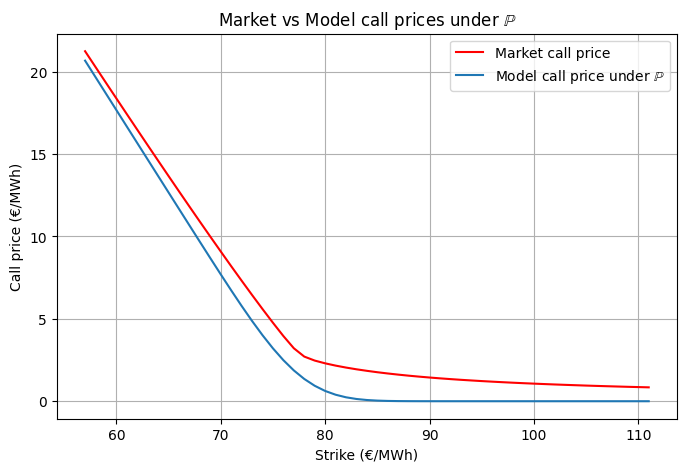

In [49]:
import pyarrow.parquet as pq
import pyarrow.dataset as ds

file_path = r"C:\Users\nolan\PyCharmMiscProject\option_data_DE.parquet"
dataset   = ds.dataset(file_path)

table = dataset.to_table(columns=["Date", "Maturity", "Delivery Start", "Delivery End","Strike", "Settlement Price", "F", "Option Type"])
df_options = table.to_pandas()

# ---------------------------------------------------------------- Fixed parameters
origin_date = pd.Timestamp('2023-01-01 00:00:00')
T0          = pd.Timestamp('2025-06-02') #pricing date
tau         = pd.Timestamp('2025-07-01') #option maturity
T1          = pd.Timestamp('2025-07-01') #delivery start
T2          = pd.Timestamp('2025-07-31') #delivery end
r = 0   
N = 100_000   
tau_hours = int(time_distance(tau, T0))

# ---------------------------------------------------------------- Market slice for these fixed dates
df = df_options[(df_options["Date"] == T0)
                       & (df_options["Maturity"] == tau)
                       & (df_options["Delivery Start"] == T1)
                       & (df_options["Delivery End"] == T2)
                       & (df_options["Option Type"] == 'C')].sort_values('Strike').reset_index(drop=True)

if df.empty:
    raise ValueError('No market data found for the selected (T0, tau, T1, T2) slice.')


# ------------------------------------------------------- Model prices
ZX_tau, _ = simulate_state(tau_hours, N, dt=1, seed=0, vartheta = 0)
F_del = delivery_futures(T1, T2, ZX_tau, 0, T0, vartheta = 0)
C_mdl = model_prices_vectorised(F_del, w, K, 0, tau_hours)


strikes = df['Strike'].to_numpy()
C_mkt   = df['Settlement Price'].to_numpy()
F = df['F'].to_numpy()[0]
df["Model Price"] = C_mdl

print(f'{len(strikes)} strikes found for T0={T0.date()}, tau={tau.date()}, 'f'delivery=[{T1.date()}, {T2.date()}]')
print(df[['Strike', 'F', 'Settlement Price', 'Model Price']])

plt.figure(figsize=(8, 5))
plt.plot(strikes, C_mkt, color='red', label='Market call price')
plt.plot(strikes, C_mdl, label='Model call price under $\\mathbb{P}$')
plt.xlabel("Strike (€/MWh)")
plt.ylabel("Call price (€/MWh)")
plt.title("Market vs Model call prices under $\\mathbb{P}$")
plt.legend()
plt.grid(True)
plt.show()

### Esscher tilt optimizer on prices
$$\min_{\vartheta_X} \sum_j w_j \left(C^{\rm mdl}(K_j, T_1^j, T_2^j; \vartheta_X) - C^{\rm mkt}(K_j, T_1^j, T_2^j)\right)^2 \quad \text{s.t.} \quad |\beta^\mathbb{P} + \vartheta_X| < \alpha^\mathbb{P}$$

In [50]:
from scipy.optimize import minimize_scalar


def calibrate_vartheta(
    strikes: np.ndarray,
    C_mkt: np.ndarray,
    T0: pd.Timestamp,
    tau: pd.Timestamp,
    T1: pd.Timestamp,
    T2: pd.Timestamp,
    weights_mkt: np.ndarray | None = None,
    N: int = 100_000,
    r: float = 0.0,
    dt: float = 1.0,
    seed: int = 0,
    ess_threshold: float = 0.2,
    verbose: bool = True
) -> dict:
    """
    Vectorised Stage 2 calibration : for fixed (T0, tau, T1, T2), find the single
    vartheta_X minimising the weighted squared error against market call prices
    across all strikes simultaneously.

    Parameters
    strikes      : (J,)  market strikes K_j
    C_mkt        : (J,)  market call prices C_mkt(K_j)
    T0, tau      : pricing date and option exercise date
    T1, T2       : delivery period
    weights_mkt  : (J,)  optional weights w_j in the loss (default : uniform)
    N            : number of MC paths (simulated once)
    r            : annual risk-free rate
    dt           : simulation step in hours
    seed         : random seed
    ess_threshold: minimum ESS/N defining the admissible tilt domain
    verbose      : print calibration diagnostics

    Returns
    dict with keys :
        vartheta_opt, beta_Q, obj_value, C_mdl_opt, ess_opt,
        vartheta_bounds, result, ZX_tau, LX_cumulated
    """
    strikes = np.asarray(strikes, dtype=float)
    C_mkt   = np.asarray(C_mkt,   dtype=float)
    if weights_mkt is None:
        weights_mkt = np.ones_like(strikes)
    weights_mkt = np.asarray(weights_mkt, dtype=float)

    tau_hours = time_distance(tau, T0)

    # ---------------------------------------------------------------- Step 1 : simulate once under P
    if verbose:
        print(f'Step 1 — Simulating {N} paths under P ...')
    ZX_tau, LX_cumulated = simulate_state(tau_hours, N, dt=dt, seed=seed, vartheta = 0)
    if verbose:
        print(f'Done : ZX_tau {ZX_tau.shape}, LX_cumulated {LX_cumulated.shape}')

    # ---------------------------------------------------------------- Step 2 : ESS-admissible bounds
    if verbose:
        print('\nStep 2 — Computing ESS-admissible tilt domain ...')
    vartheta_min_ess, vartheta_max_ess = ess_admissible_bounds(LX_cumulated, tau_hours, ess_threshold=ess_threshold)

    # ---------------------------------------------------------------- Step 3 : vectorised objective
    iter_count = [0]

    def objective(vartheta_X: float) -> float:
        iter_count[0] += 1

        F_del         = delivery_futures(T1, T2, ZX_tau, tau_hours, T0, vartheta_X)
        w_norm, ess   = esscher_weights(vartheta_X, LX_cumulated, tau_hours)
        C_mdl         = model_prices_vectorised(F_del, w_norm, strikes, r, tau_hours)   # (J,)

        loss = float(np.sum(weights_mkt * (C_mdl - C_mkt) ** 2))

        if verbose:
            print(f'  iter {iter_count[0]:3d} | vartheta={vartheta_X:+.6f} 'f'| beta^Q={beta_X+vartheta_X:+.6f} | loss={loss:.6e} | ESS/N={ess:.3f}')
        return loss

    # ---------------------------------------------------------------- Step 4 : optimise
    if verbose:
        print('\nStep 3 — Optimising vartheta_X over the ESS-admissible domain ...')

    result = minimize_scalar(objective, bounds=(vartheta_min_ess, vartheta_max_ess), method='bounded', options={'xatol': 1e-2, 'maxiter': 500})

    vartheta_opt = result.x
    beta_Q       = beta_X + vartheta_opt

    # ---------------------------------------------------------------- Final prices at optimum
    F_del_opt        = delivery_futures(T1, T2, ZX_tau, tau_hours, T0, vartheta_opt)
    w_opt, ess_opt    = esscher_weights(vartheta_opt, LX_cumulated, tau_hours)
    C_mdl_opt         = model_prices_vectorised(F_del_opt, w_opt, strikes, r, tau_hours)

    if verbose:
        print('\n' + '=' * 60)
        print(f'  vartheta_X*  = {vartheta_opt:+.8f}')
        print(f'  beta^P       = {beta_X:+.8f}')
        print(f'  beta^Q       = {beta_Q:+.8f}')
        print(f'  ESS/N at opt = {ess_opt:.4f}')
        print(f'  Loss (min)   = {result.fun:.6e}')
        print('=' * 60)
        print(f'\n  {"Strike":>10}  {"C_mkt":>10}  {"C_mdl_opt":>10}  {"Error":>10}')
        for K_j, C_mkt_j, C_mdl_j in zip(strikes, C_mkt, C_mdl_opt):
            print(f'  {K_j:10.2f}  {C_mkt_j:10.4f}  {C_mdl_j:10.4f}  {C_mdl_j-C_mkt_j:+10.4f}')
    '''
    plt.figure(figsize=(8, 5))
    plt.plot(strikes, C_mkt, 'o-', label='Market prices $C_{mkt}$')
    plt.plot(strikes, C_mdl_opt, 's--', label='Model prices $C_{mdl}^{opt}$')
    plt.xlabel('Strike')
    plt.ylabel('Call price')
    plt.title('Market vs model call prices')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()
    '''
    return {'vartheta_opt'   : vartheta_opt,
            'beta_Q'         : beta_Q,
            'obj_value'      : result.fun,
            'C_mdl_opt'      : C_mdl_opt,
            'ess_opt'        : ess_opt,
            'vartheta_bounds': (vartheta_min_ess, vartheta_max_ess),
            'result'         : result,
            'ZX_tau'         : ZX_tau,
            'LX_cumulated'   : LX_cumulated,}


Step 1 — Simulating 100000 paths under P ...
Done : ZX_tau (100000, 5), LX_cumulated (100000,)

Step 2 — Computing ESS-admissible tilt domain ...
Admissible tilt domain (ESS/N > 0.2) : [-3.952953, 3.997203]
(Full NIG strip was : [-42.393343, 52.540540])

Step 3 — Optimising vartheta_X over the ESS-admissible domain ...
  iter   1 | vartheta=-0.916264 | beta^Q=-5.989862 | loss=6.126019e+02 | ESS/N=0.916
  iter   2 | vartheta=+0.960514 | beta^Q=-4.113085 | loss=3.665402e+02 | ESS/N=0.910
  iter   3 | vartheta=+2.120426 | beta^Q=-2.953172 | loss=2.416224e+03 | ESS/N=0.633
  iter   4 | vartheta=+0.126996 | beta^Q=-4.946602 | loss=4.770413e+01 | ESS/N=0.998
  iter   5 | vartheta=+0.155276 | beta^Q=-4.918322 | loss=4.552964e+01 | ESS/N=0.998
  iter   6 | vartheta=+0.208523 | beta^Q=-4.865076 | loss=4.368718e+01 | ESS/N=0.996
  iter   7 | vartheta=+0.215254 | beta^Q=-4.858345 | loss=4.366629e+01 | ESS/N=0.995
  iter   8 | vartheta=+0.218587 | beta^Q=-4.855011 | loss=4.367370e+01 | ESS/N=0.995

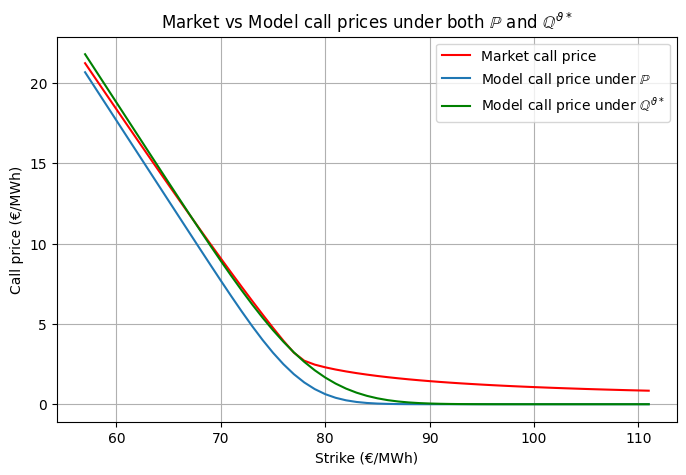

In [51]:
file_path = r"C:\Users\nolan\PyCharmMiscProject\option_data_DE.parquet"
dataset   = ds.dataset(file_path)

table = dataset.to_table(columns=["Date", "Maturity", "Delivery Start", "Delivery End","Strike", "Settlement Price", "F", "Option Type"])
df_options = table.to_pandas()

# ---------------------------------------------------------------- Fixed parameters
origin_date = pd.Timestamp('2023-01-01 00:00:00')
T0          = pd.Timestamp('2025-06-02') #pricing date
tau         = pd.Timestamp('2025-07-01') #option maturity
T1          = pd.Timestamp('2025-07-01') #delivery start
T2          = pd.Timestamp('2025-07-31') #delivery end
r = 0   
N = 100_000   
tau_hours = int(time_distance(tau, T0))

# ---------------------------------------------------------------- Market slice for these fixed dates
df = df_options[(df_options["Date"] == T0)
                & (df_options["Maturity"] == tau)
                & (df_options["Delivery Start"] == T1)
                & (df_options["Delivery End"] == T2)
                & (df_options["Option Type"] == 'C')].sort_values('Strike').reset_index(drop=True)

if df.empty:
    raise ValueError('No market data found for the selected (T0, tau, T1, T2) slice.')


# ------------------------------------------------------- Model prices
ZX_tau, _ = simulate_state(tau_hours, N, dt=1, seed=0, vartheta = 0)
F_del = delivery_futures(T1, T2, ZX_tau, 0, T0, vartheta = 0)
C_mdl = model_prices_vectorised(F_del, w, K, 0, tau_hours)


strikes = df['Strike'].to_numpy()
C_mkt   = df['Settlement Price'].to_numpy()
F = df['F'].to_numpy()[0]
df["Model Price"] = C_mdl

# Optimal prices
optimum = calibrate_vartheta(strikes = strikes, C_mkt = C_mkt, T0 = T0, tau = tau,  T1 = T1, T2 = T2,
                             N = N, r = r, dt = 1.0, seed = 0, ess_threshold = 0.2, verbose = True)
C_opt = optimum['C_mdl_opt']
df['Optimal Price'] = C_opt

print(f'{len(strikes)} strikes found for T0={T0.date()}, tau={tau.date()}, 'f'delivery=[{T1.date()}, {T2.date()}]')
print(df[['Strike', 'F', 'Settlement Price', 'Model Price', 'Optimal Price']])

plt.figure(figsize=(8, 5))
plt.plot(strikes, C_mkt, color='red', label='Market call price')
plt.plot(strikes, C_mdl, label='Model call price under $\\mathbb{P}$')
plt.plot(strikes, C_opt, color='green', label='Model call price under $\\mathbb{Q}^{\\vartheta*}$')

plt.xlabel("Strike (€/MWh)")
plt.ylabel("Call price (€/MWh)")
plt.title("Market vs Model call prices under both $\\mathbb{P}$ and $\\mathbb{Q}^{\\vartheta*}$")
plt.legend()
plt.grid(True)
plt.show()

$$\star \star \star$$